## Rules-Based Approach

**Goal:** See how well the rules-based approach works on the predictions to cut down on false positives from the predictions from the original model.

In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm.notebook import tqdm
import pickle
import os

In [2]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
dateformat = DateFormatter(fmt = '%H:%M:%S:%f')

def plot_event(idx, shift = 0):
    duration = 20
    
    readings_sub = (
        readings
        .loc[idx - shift:idx - shift + duration - 1]
        [['Channel_' + str(i) for i in range(1,7)]]
        .values
    )

    fig, ax = plt.subplots(figsize = (12,6))
    times = readings.loc[idx - shift:idx - shift + duration - 1, 'Time']

    for i in range(6):
        if i == 0:
            color = 'blue'
        elif i == 1:
            color = 'red'
        elif i == 4:
            color = 'yellow'
        elif i == 5:
            color = 'black'
        else:
            color = 'grey'
        
        plt.plot(times, readings_sub[:, i], label = 'Channel_' + str(i + 1), color=color)

    ax.xaxis.set_major_formatter(dateformat)

    plt.legend(bbox_to_anchor = (1, 0.5), loc = 'center left')
    plt.ylim(-500, 10500)

In [3]:
def import_data_new(patient_num):

    # First, get the labels
    labels = pd.read_csv(f'../data/new_2024/centered/centered_{patient_num}.csv')

    others = pd.read_csv(f'../data/new_2024/double_check/dc_{patient_num}.csv')
    
    sgb_times = pd.concat([labels[['Time']], others[['Time']]])
    
    additional_files = glob.glob("../data/new_2024/additional/*.csv")
    if f"../data/new_2024/additional/fp_{patient_num}.csv" in additional_files:
        additional = pd.read_csv(f'../data/new_2024/additional/fp_{patient_num}.csv')
        additional = additional[additional['keep'] == True]
        additional = additional.rename(columns={'timestamp': 'Time'})
        sgb_times = pd.concat([sgb_times[['Time']], additional[['Time']]])
    
    sgb_times['Time'] = pd.to_datetime(sgb_times['Time'])
    sgb_times['sgb'] = True

    # Then the raw data
    readings = pd.read_csv(f'../data/new_data/eval_data/{patient_num} RAW 00.csv')
    readings['Time'] = pd.to_datetime(readings['Time'])
    readings['CapturedTime'] = readings['Time'].dt.time

    # Combine them to label the events times
    readings = pd.merge(left = readings,
             right = sgb_times[['Time', 'sgb']],
            how = 'outer').fillna('False')
    
    # Then remove the meal times
    events = pd.read_csv(f'../data/new_data/eval_data/{patient_num} EVT 00.csv')
    events = events[events['EventName'] == 'Meal']
    events['Time'] = pd.to_datetime(events['Time'])
    events['Duration'] = pd.to_timedelta(events['Duration'])
    events = events.assign(End = events['Time'] + events['Duration'])
    for idx, row in events.iterrows():
        readings = readings[(readings['Time'] < row['Time']) | (readings['Time'] > row['End'])]
        
#     # Normalize the readings to be between 0 and 1
#     for channel in [
#         'Channel_1', 'Channel_2', 'Channel_3',
#         'Channel_4', 'Channel_5', 'Channel_6'
#     ]:
#         readings[channel] = readings[channel] / 10000
    readings = readings.copy()
    readings['sgb'] = readings['sgb'].replace('False', False)
    
    return readings

In [504]:
patient_num = '99' 
readings = import_data_new(patient_num)

First, find rises of 1000 that occur within 0.3 seconds.

In [505]:
channel_num = 1

rise_time = 2
rise_threshold = 800

for channel_num in [1, 2, 5, 6]:
    readings[f'Channel_{channel_num}_rise'] = (readings[f'Channel_{channel_num}'] - readings[f'Channel_{channel_num}'].shift(rise_time)) > rise_threshold

Then, find all falls that occur within 0.3 seconds.

In [506]:
channel_num = 1

fall_time = 2
fall_threshold = 1000

for channel_num in [1, 2, 5, 6]:
    readings[f'Channel_{channel_num}_fall'] = (readings[f'Channel_{channel_num}'].shift(fall_time) - readings[f'Channel_{channel_num}']) > fall_threshold

Potential Update:
* Consider only the first rise and last fall, but checking that there isn't another rise in the prior 0.2 seconds or fall in the following 0.2 seconds.

In [507]:
for channel_num in [1, 2, 5, 6]:
    readings[f'Channel_{channel_num}_rise'] = (
        (readings[f'Channel_{channel_num}_rise']) & (~readings[f'Channel_{channel_num}_rise'].shift(1).astype(bool)) & (~readings[f'Channel_{channel_num}_rise'].shift(2).astype(bool))
    )
    
    readings[f'Channel_{channel_num}_fall'] = (
        (readings[f'Channel_{channel_num}_fall']) & (~readings[f'Channel_{channel_num}_fall'].shift(-1).astype(bool)) & (~readings[f'Channel_{channel_num}_fall'].shift(-2).astype(bool))
    )

Find all local max values. To be a local max, it must be larger than any value in the one second prior and one second after.

In [508]:
window_size = 21

for channel_num in [1, 2, 5, 6]:
    readings[f'Channel_{channel_num}_local_max'] = readings[f'Channel_{channel_num}'] == readings[f'Channel_{channel_num}'].rolling(window = window_size, center = True).max()

Then pass the location and value of the next local max value backwards.

In [509]:
for channel_num in [1, 2, 5, 6]:
    readings.loc[readings[f'Channel_{channel_num}_local_max'], f'Channel_{channel_num}_next_local_max_idx'] = readings.loc[readings[f'Channel_{channel_num}_local_max']].index
    readings.loc[readings[f'Channel_{channel_num}_local_max'], f'Channel_{channel_num}_next_local_max_value'] = readings.loc[readings[f'Channel_{channel_num}_local_max'], f'Channel_{channel_num}']
    
    readings[f'Channel_{channel_num}_next_local_max_idx'] = readings[f'Channel_{channel_num}_next_local_max_idx'].bfill()
    readings[f'Channel_{channel_num}_next_local_max_value'] = readings[f'Channel_{channel_num}_next_local_max_value'].bfill()

Then find the value that it needs to drop to in order to qualify.
This will be halfway between the value before the drop and the value at the next local max.

In [510]:
for channel_num in [1, 2, 5, 6]:
    # Establish the baseline by finding the smallest value in the last 0.5 seconds
    baseline_window_size = 5
    readings[f'Channel_{channel_num}_prior'] = readings[f'Channel_{channel_num}'].rolling(baseline_window_size).min()
    readings[f'Channel_{channel_num}_drop_threshold'] = readings[f'Channel_{channel_num}_prior'] + 0.4 * (readings[f'Channel_{channel_num}_next_local_max_value'] - readings[f'Channel_{channel_num}_prior'])
    

Similar to the local maxes, pass the next fall information backwards.

In [511]:
for channel_num in [1, 2, 5, 6]:
    readings.loc[readings[f'Channel_{channel_num}_fall'], f'Channel_{channel_num}_next_fall_idx'] = readings.loc[readings[f'Channel_{channel_num}_fall']].index
    readings.loc[readings[f'Channel_{channel_num}_fall'], f'Channel_{channel_num}_next_fall_value'] = readings.loc[readings[f'Channel_{channel_num}_fall'], f'Channel_{channel_num}']
    
    readings[f'Channel_{channel_num}_next_fall_idx'] = readings[f'Channel_{channel_num}_next_fall_idx'].bfill()
    readings[f'Channel_{channel_num}_next_fall_value'] = readings[f'Channel_{channel_num}_next_fall_value'].bfill()

REVISION

Check the next time it falls below the fall index.

In [512]:
window = 20
n = len(readings)


for channel_num in [1, 2, 5, 6]:
    values = readings[f'Channel_{channel_num}'].to_numpy()
    thresholds = readings[f"Channel_{channel_num}_drop_threshold"].to_numpy()

    # Build future values (n x window)
    future_vals = np.empty((n, window))
    future_vals[:] = np.nan

    for k in range(1, window + 1):
        future_vals[:-k, k-1] = values[k:]
    mask = future_vals < thresholds[:, None]
    
    # Convert index value to integer position
    start_pos = readings.index.searchsorted(readings[f"Channel_{channel_num}_next_local_max_idx"])
    start_pos = np.where(start_pos == -1, n, start_pos)
    
    # Future positions
    future_pos = np.arange(n)[:, None] + np.arange(1, window + 1)

    # Apply constraints
    valid = (future_pos < n) & (future_pos >= start_pos[:, None])
    mask &= valid

    # First match
    has_hit = mask.any(axis=1)
    offsets = np.where(has_hit, mask.argmax(axis=1) + 1, -1)

    next_idx = np.where(offsets != -1, np.arange(n) + offsets, -1)

    readings[f"Channel_{channel_num}_next_fall_idx"] = np.where(
        next_idx != -1,
        readings.index.to_numpy()[next_idx],
        np.nan  # or pd.NaT if it's a DatetimeIndex
    )

OLD

Mark all rise drop pairs.
Three conditions:
1. A rise in that channel.
2. The next fall is enough to take it back to the baseline.
3. The next fall happens within 1.5 seconds.

NEW

Mark all rise drop pairs.
Two conditions:
1. A rise in that channel.
2. A return to baseline in the next 2 seconds.

In [513]:
max_dist_between_rise_and_fall = 30

for channel_num in [1, 2, 5, 6]:
    #readings[f'Channel_{channel_num}_rise_drop_pair'] = (readings[f'Channel_{channel_num}_rise']) & (readings[f'Channel_{channel_num}_next_fall_value'] < readings[f'Channel_{channel_num}_drop_threshold']) & ((readings[f'Channel_{channel_num}_next_fall_idx'] - readings.index) <= max_dist_between_rise_and_fall) 
    readings[f'Channel_{channel_num}_rise_drop_pair'] = (readings[f'Channel_{channel_num}_rise']) & (readings[f'Channel_{channel_num}_next_fall_idx'].notna())

Now check the following:
1. Channel 1 or 2 is a rise_drop_pair
2. Channel 5 or 6 has a rise_drop_pair within 0.3 seconds.
3. There is not a rise_drop_pair in channel 5 or 6 in the prior 0.3 seconds.
4. The next_fall_value for Channel 1 or 2 happens earlier than the next_fall_value for 5 or 6.

In [514]:
for (i,j) in [(1, 5), (1,6), (2,5), (2,6)]:

    readings[f'Channel_{i}_{j}_nest'] = (


        (readings[f'Channel_{i}_rise_drop_pair']) & \
        (~readings[f'Channel_{j}_rise_drop_pair'].shift(1).astype(bool)) & \
        (
            (
                (readings[f'Channel_{j}_rise_drop_pair']) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'])) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-1) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-1))) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-2) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-2))) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-3) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-3))) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-4) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-4))) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-5) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-5))) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-6) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-6))) | \
                (readings[f'Channel_{j}_rise_drop_pair'].shift(-7) & (readings[f'Channel_{i}_next_fall_idx'] >= readings[f'Channel_{j}_next_fall_idx'].shift(-7)))


        )
    )


In [515]:
readings['flag'] = (readings['Channel_1_5_nest']) | (readings['Channel_1_6_nest']) | (readings['Channel_2_5_nest']) | (readings['Channel_2_6_nest'])

In [516]:
## Look for a flag soon after
readings = readings.iloc[::-1]

window_size = 15
readings[f'flag_soon'] = readings[f'flag'].rolling(window = window_size).max().astype(bool)

readings = readings.iloc[::-1]

window_size = 5

readings['sgb_soon_before'] = readings['sgb'].rolling(window=window_size).max().astype(bool)

readings = readings.iloc[::-1]

readings[f'sgb_soon_after'] = readings['sgb'].rolling(window=window_size).max().astype(bool)

readings = readings.iloc[::-1]

readings['sgb_near'] = (readings['sgb_soon_before']) | (readings['sgb_soon_after'])



window_size = 20

readings['flag_soon_before'] = readings['flag'].rolling(window=window_size).max().astype(bool)

readings = readings.iloc[::-1]

readings[f'flag_soon_after'] = readings['flag'].rolling(window=window_size).max().astype(bool)

readings = readings.iloc[::-1]

readings['flag_near'] = (readings['flag_soon_before']) | (readings['flag_soon_after'])

In [517]:
fp = readings[(readings['flag']) & (~readings['sgb_near'])].index.tolist()

prediction_indices = readings[readings['flag']].index.tolist()
total_events = readings["sgb"].sum()

true_indices = readings[readings['sgb'] == True].index.tolist()

true_positives = []
false_positives = []
for idx in tqdm(prediction_indices):
    fp = True
    for i in range(15):
        if idx - i in true_indices:
            true_positives.append(idx - i)
            fp = False
            continue
        if idx + i in true_indices:
            true_positives.append(idx + i)
            fp = False
            continue
    if fp:
        false_positives.append(idx)
        
true_positives = set(true_positives)

false_positives = pd.DataFrame({'fp_index': false_positives})
false_positives['diff'] = false_positives['fp_index'].diff()
false_positives = false_positives[~(false_positives['diff'].isin([1, 2, 3, 4, 5]))]['fp_index'].tolist()

print(f'True Positives: {len(true_positives)}')
print(f'Missed: {len(missed)}')
print(f'Sensitivity: {round(len(true_positives) / total_events, 3)}')
print(f'False Positives: {len(false_positives)}')

  0%|          | 0/29 [00:00<?, ?it/s]

True Positives: 8
Missed: 7
Sensitivity: 0.533
False Positives: 16


In [518]:
missed = readings[(readings['sgb']) & (~readings['flag_near'])].index.tolist()
print(f"Total Events: {readings['sgb'].sum()}")
print(f"Number Filtered Out: {len(missed)}")

Total Events: 15
Number Filtered Out: 7


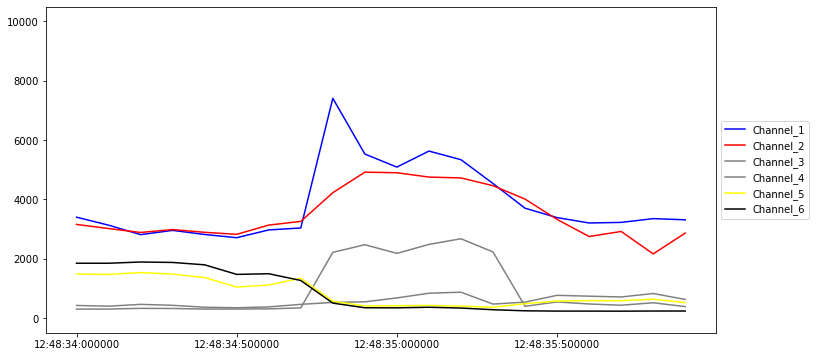

In [527]:
i = 0

idx = missed[i]
plot_event(idx)

In [502]:
i = 1
j = 5

readings.loc[idx:idx+20,
            [
                'Time',
                f'Channel_{i}',
                f'Channel_{i}_rise',
                #f'Channel_{i}_prior',
                #f'Channel_{i}_next_local_max_value',
                #f'Channel_{i}_fall',
                f'Channel_{i}_next_fall_idx',
                f'Channel_{i}_drop_threshold',
                f'Channel_{i}_rise_drop_pair',
                f'Channel_{j}',
                f'Channel_{j}_rise',
                #f'Channel_{j}_fall',
                f'Channel_{j}_next_fall_idx',
                f'Channel_{j}_rise_drop_pair'
                
            ]
            ]

,Time,Channel_1,Channel_1_rise,Channel_1_next_fall_idx,Channel_1_drop_threshold,Channel_1_rise_drop_pair,Channel_5,Channel_5_rise,Channel_5_next_fall_idx,Channel_5_rise_drop_pair
400193,2017-11-14 22:19:27.300,2339.33,False,400207.0,3740.982,False,986.53,False,400205.0,False
400194,2017-11-14 22:19:27.400,2380.85,False,400207.0,3783.468,False,1013.39,False,400205.0,False
400195,2017-11-14 22:19:27.500,2451.66,False,400207.0,3801.054,False,1042.69,False,400205.0,False
400196,2017-11-14 22:19:27.600,2456.55,False,400207.0,3801.054,False,1059.78,False,400205.0,False
400197,2017-11-14 22:19:27.700,2556.66,False,400207.0,3884.562,False,1054.90,False,400205.0,False
400198,2017-11-14 22:19:27.800,2588.41,False,400207.0,3909.474,False,1086.64,False,400205.0,False
400199,2017-11-14 22:19:27.900,6202.41,True,400207.0,3951.960,True,1103.74,False,400205.0,False
400200,2017-11-14 22:19:28.000,5569.96,False,NaN,5473.754,False,2192.82,True,400205.0,True
400201,2017-11-14 22:19:28.100,4346.57,False,NaN,5533.820,False,1877.82,False,NaN,False
400202,2017-11-14 22:19:28.200,4239.13,False,NaN,5552.870,False,1814.33,False,NaN,False


In [34]:
missed = readings[(readings['sgb']) & (~readings['flag_near'])].index.tolist()
len(missed)

7

In [35]:
fp = readings[(readings['flag']) & (~readings['sgb_near'])].index.tolist()
len(fp)

1793

In [36]:
fp = readings[(readings['flag']) & (~readings['sgb_near'])].index.tolist()

prediction_indices = readings[readings['flag']].index.tolist()
total_events = readings["sgb"].sum()

true_indices = readings[readings['sgb'] == True].index.tolist()

true_positives = []
false_positives = []
for idx in tqdm(prediction_indices):
    fp = True
    for i in range(15):
        if idx - i in true_indices:
            true_positives.append(idx - i)
            fp = False
            continue
        if idx + i in true_indices:
            true_positives.append(idx + i)
            fp = False
            continue
    if fp:
        false_positives.append(idx)
        
true_positives = set(true_positives)

false_positives = pd.DataFrame({'fp_index': false_positives})
false_positives['diff'] = false_positives['fp_index'].diff()
false_positives = false_positives[~(false_positives['diff'].isin([1, 2, 3, 4, 5]))]['fp_index'].tolist()

print(f'True Positives: {len(true_positives)}')
print(f'Missed: {len(missed)}')
print(f'Sensitivity: {round(len(true_positives) / total_events, 3)}')
print(f'False Positives: {len(false_positives)}')

  0%|          | 0/2051 [00:00<?, ?it/s]

True Positives: 291
Missed: 7
Sensitivity: 0.977
False Positives: 465


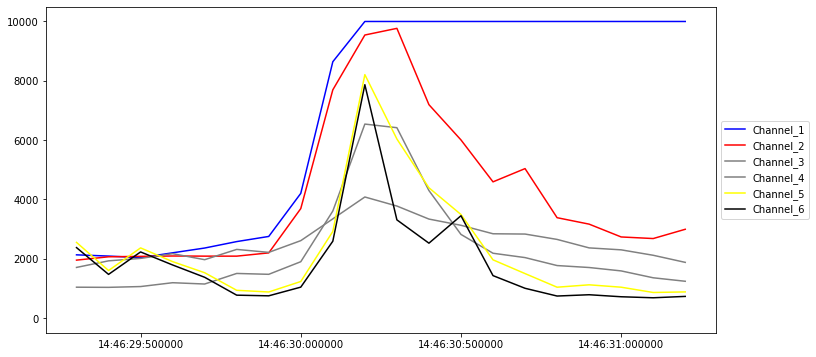

In [37]:
i = 0

idx = missed[i]
plot_event(idx)

In [38]:
readings.loc[idx:idx+15, ['Time',
                          'Channel_1',
                          'Channel_1_rise',
                          'Channel_1_next_return_after_max',
                            'Channel_2',
                          'Channel_2_rise',
                          'Channel_2_next_return_after_max',
                          'Channel_5',
                          'Channel_5_rise',
                          'Channel_5_next_return_after_max',
                            'Channel_6',
                          'Channel_6_rise',
                          'Channel_6_next_return_after_max',
                         ]]

,Time,Channel_1,Channel_1_rise,Channel_1_next_return_after_max,Channel_2,Channel_2_rise,Channel_2_next_return_after_max,Channel_5,Channel_5_rise,Channel_5_next_return_after_max,Channel_6,Channel_6_rise,Channel_6_next_return_after_max
6093,2016-08-30 14:46:29.300,2129.33,False,6127.0,1951.07,False,6108.0,2549.34,True,6107.0,2373.52,True,6106.0
6094,2016-08-30 14:46:29.400,2087.82,False,6127.0,2063.40,False,6108.0,1599.44,True,6107.0,1470.02,True,6106.0
6095,2016-08-30 14:46:29.500,2034.10,False,6127.0,2078.05,False,6108.0,2363.75,True,6107.0,2227.01,True,6106.0
6096,2016-08-30 14:46:29.600,2197.71,False,6127.0,2090.26,False,6108.0,1899.79,True,6107.0,1787.47,True,6106.0
6097,2016-08-30 14:46:29.700,2358.87,False,6127.0,2085.38,False,6108.0,1526.18,False,6107.0,1372.34,False,6106.0
6098,2016-08-30 14:46:29.800,2576.20,False,6127.0,2085.38,False,6108.0,932.80,False,6107.0,769.20,False,6106.0
6099,2016-08-30 14:46:29.900,2749.57,True,6127.0,2195.26,False,6108.0,876.64,False,6107.0,747.22,False,6106.0
6100,2016-08-30 14:46:30.000,4202.50,True,6127.0,3689.70,True,6108.0,1230.71,False,6107.0,1040.25,False,6106.0
6101,2016-08-30 14:46:30.100,8641.86,True,6127.0,7694.41,True,6108.0,2918.06,True,6107.0,2588.41,True,6106.0
6102,2016-08-30 14:46:30.200,9999.56,True,6127.0,9542.92,True,6108.0,8207.21,True,6107.0,7867.78,True,6106.0


In [39]:
print(len(false_positives))

465


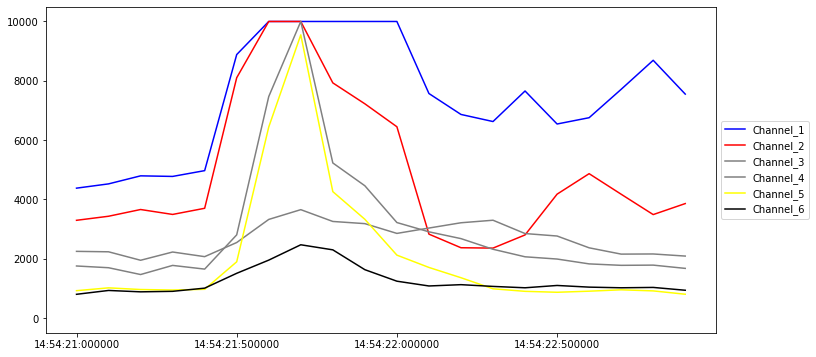

In [40]:
i = 16

idx = false_positives[i] - 5
plot_event(idx)

In [41]:
readings.loc[idx-5:idx+15, ['Time',
                          'Channel_1',
                          'Channel_1_rise',
                          'Channel_1_next_return_after_max',
                            'Channel_2',
                          'Channel_2_rise',
                          'Channel_2_next_return_after_max',
                          'Channel_5',
                          'Channel_5_rise',
                          'Channel_5_next_return_after_max',
                            'Channel_6',
                          'Channel_6_rise',
                          'Channel_6_next_return_after_max',
                         ]]

,Time,Channel_1,Channel_1_rise,Channel_1_next_return_after_max,Channel_2,Channel_2_rise,Channel_2_next_return_after_max,Channel_5,Channel_5_rise,Channel_5_next_return_after_max,Channel_6,Channel_6_rise,Channel_6_next_return_after_max
10805,2016-08-30 14:54:20.500,4463.78,False,10822.0,3286.79,False,10821.0,954.78,False,10821.0,810.71,False,10819.0
10806,2016-08-30 14:54:20.600,4427.15,False,10822.0,3240.39,False,10821.0,1045.13,False,10821.0,913.27,False,10819.0
10807,2016-08-30 14:54:20.700,3889.94,False,10822.0,2913.18,False,10821.0,991.41,False,10821.0,866.87,False,10819.0
10808,2016-08-30 14:54:20.800,3982.73,False,10822.0,2869.23,False,10821.0,1176.99,False,10821.0,1052.46,False,10819.0
10809,2016-08-30 14:54:20.900,4344.13,False,10822.0,2817.95,False,10821.0,979.20,False,10821.0,849.78,False,10819.0
10810,2016-08-30 14:54:21.000,4378.32,False,10822.0,3294.12,False,10821.0,920.59,False,10821.0,798.50,False,10819.0
10811,2016-08-30 14:54:21.100,4522.39,False,10822.0,3430.86,False,10821.0,1015.83,False,10821.0,927.92,False,10819.0
10812,2016-08-30 14:54:21.200,4793.44,False,10822.0,3657.96,False,10821.0,959.66,False,10821.0,881.52,False,10819.0
10813,2016-08-30 14:54:21.300,4773.90,False,10822.0,3491.91,False,10821.0,942.57,False,10821.0,898.62,False,10819.0
10814,2016-08-30 14:54:21.400,4969.26,False,10822.0,3699.47,False,10821.0,966.99,False,10821.0,1006.06,False,10819.0
